In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.metrics import accuracy_score , classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [2]:
def Vsualize(column_name,data):

    values = data[column_name].value_counts().values.round(2)
    index = data[column_name].value_counts().index

    color = sns.color_palette('RdBu')
    plt.figure(figsize=(7,5))
    # pie chart of column
    plt.subplot(1, 2, 1)
    plt.title(f'Distribution of {column_name}')
    plt.pie(values, labels=index,autopct='%1.1f%%',colors=color)

    # Distribution of column
    plt.subplot(1, 2, 2)
    sns.histplot(data[column_name])
    plt.xticks(rotation = 45)
    plt.tight_layout() # Adjusts subplot
    plt.show()

In [3]:
def train_test_model(model,x_train,x_test,y_train,y_test):
    # Train model
    model.fit(x_train,y_train)
    # Acurracy of train data
    print(f'\n Train accuracy_score = {accuracy_score(y_train,model.predict(x_train))* 100:.2f}% \n')

    # Test model
    y_predict = model.predict(x_test)
    #Evaluate Model
    # Show accuracy_score and classification_report
    print(f'\n Test accuracy_score = {accuracy_score(y_test,y_predict)* 100:.2f}% \n')
    print(f'Test classification_report = \n {classification_report(y_test,y_predict)}')


In [4]:
path = '/kaggle/input/employee-attrition-dataset/train.csv'
data = pd.read_csv(path)

In [5]:
data

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left


In [6]:
data.shape

(59598, 24)

In [7]:
data

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [9]:
# not important columns
data.drop(['Employee ID'],axis = 1,inplace = True)

In [10]:
data.duplicated().sum()

0

In [11]:
data.isnull().sum()

Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [12]:
data['Attrition'].value_counts()

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

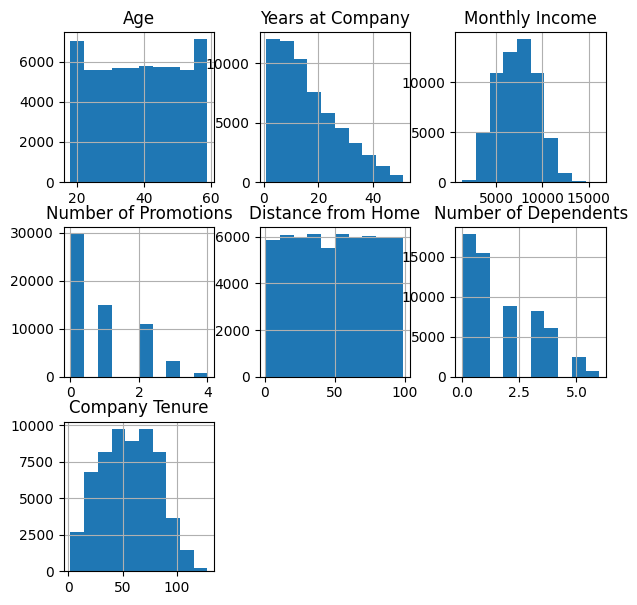

In [13]:
data.hist(figsize=(7,7))
plt.show()

In [14]:
object_data = data.select_dtypes(include = 'object')

In [15]:
object_data.columns

Index(['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Overtime', 'Education Level', 'Marital Status',
       'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

Gender
Male      32739
Female    26859
Name: count, dtype: int64


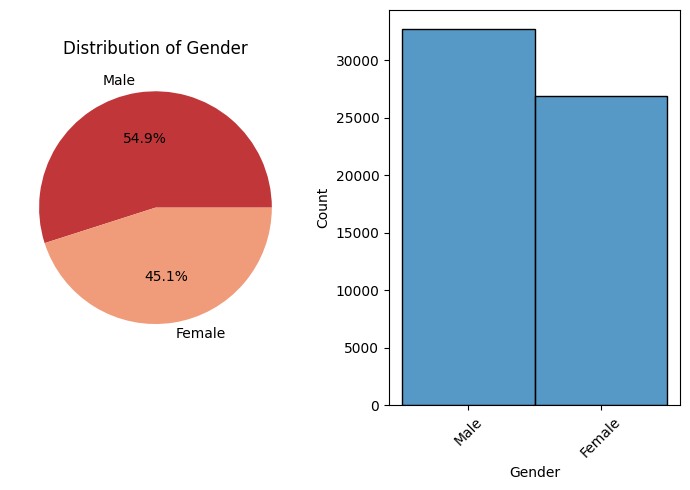

Job Role
Technology    15507
Healthcare    13642
Education     12490
Media          9574
Finance        8385
Name: count, dtype: int64


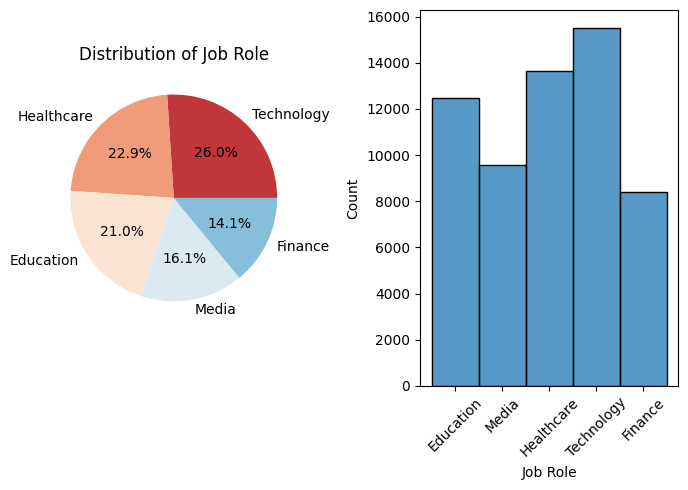

Work-Life Balance
Good         22528
Fair         18046
Excellent    10719
Poor          8305
Name: count, dtype: int64


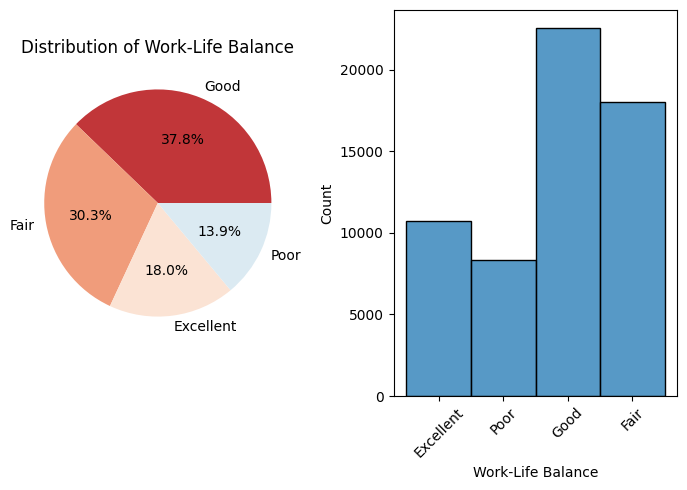

Job Satisfaction
High         29779
Very High    12111
Medium       11817
Low           5891
Name: count, dtype: int64


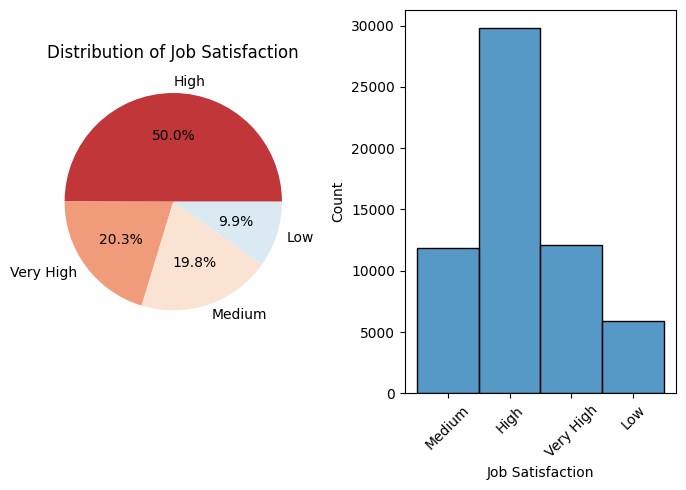

Performance Rating
Average          35810
High             11888
Below Average     8950
Low               2950
Name: count, dtype: int64


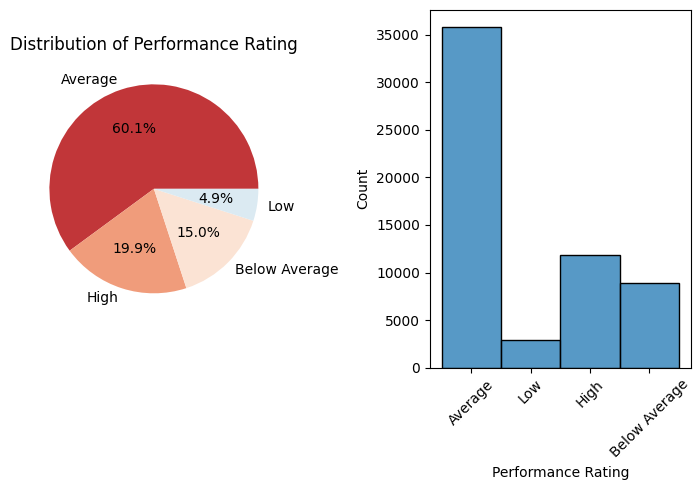

Overtime
No     40148
Yes    19450
Name: count, dtype: int64


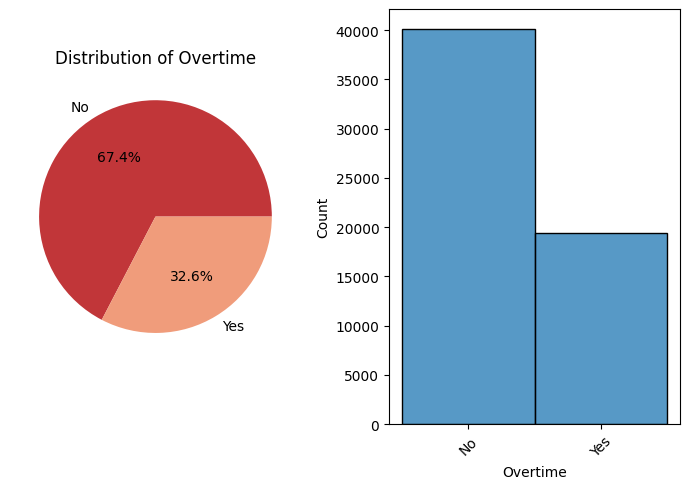

Education Level
Bachelor’s Degree    17826
Associate Degree     14915
Master’s Degree      12020
High School          11748
PhD                   3089
Name: count, dtype: int64


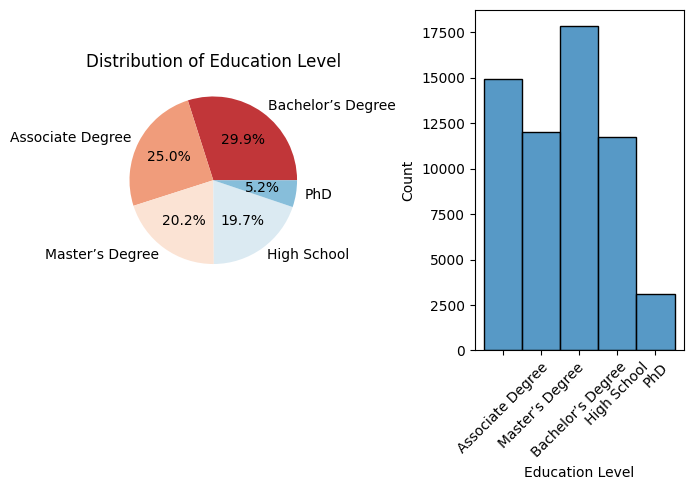

Marital Status
Married     29908
Single      20835
Divorced     8855
Name: count, dtype: int64


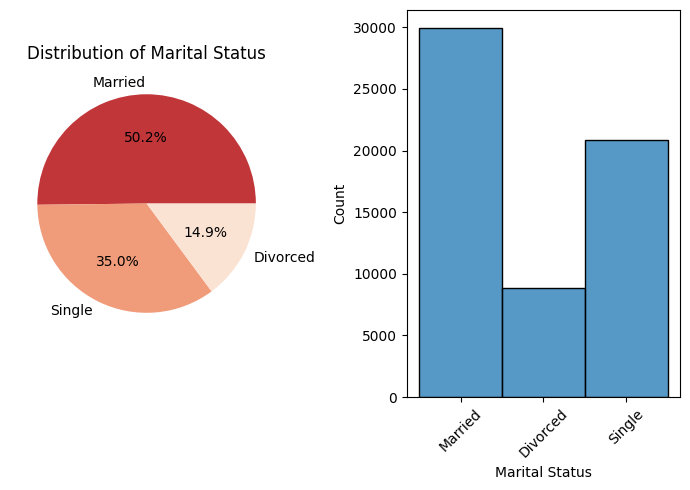

Job Level
Entry     23867
Mid       23753
Senior    11978
Name: count, dtype: int64


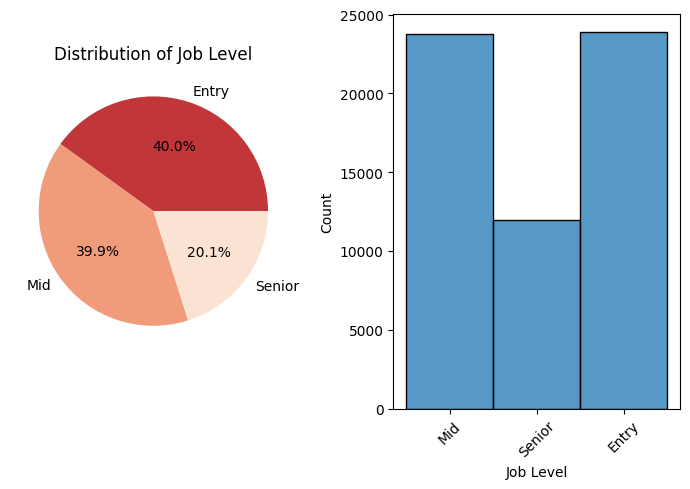

Company Size
Medium    29745
Small     17935
Large     11918
Name: count, dtype: int64


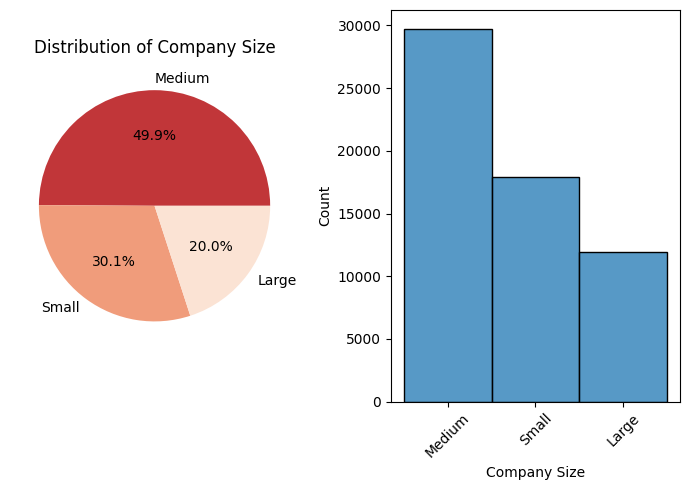

Remote Work
No     48239
Yes    11359
Name: count, dtype: int64


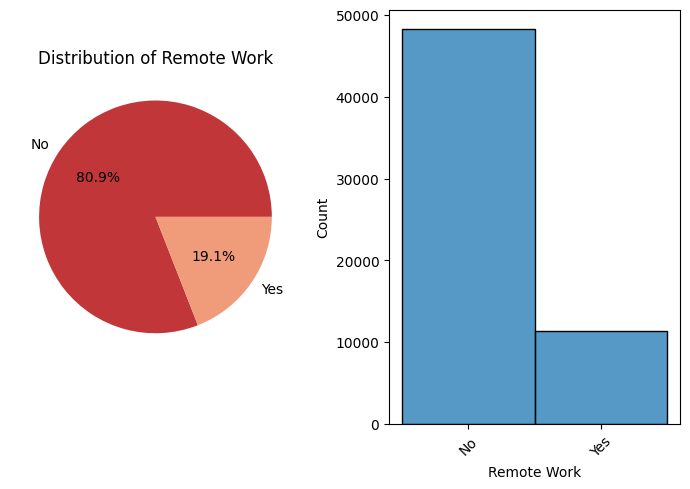

Leadership Opportunities
No     56680
Yes     2918
Name: count, dtype: int64


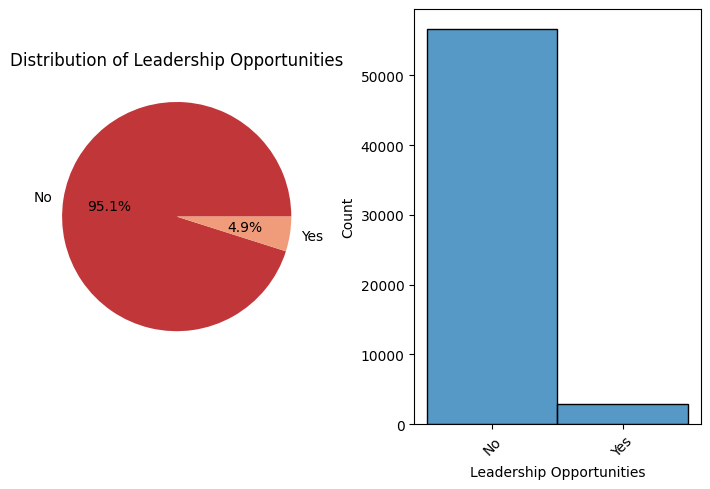

Innovation Opportunities
No     49895
Yes     9703
Name: count, dtype: int64


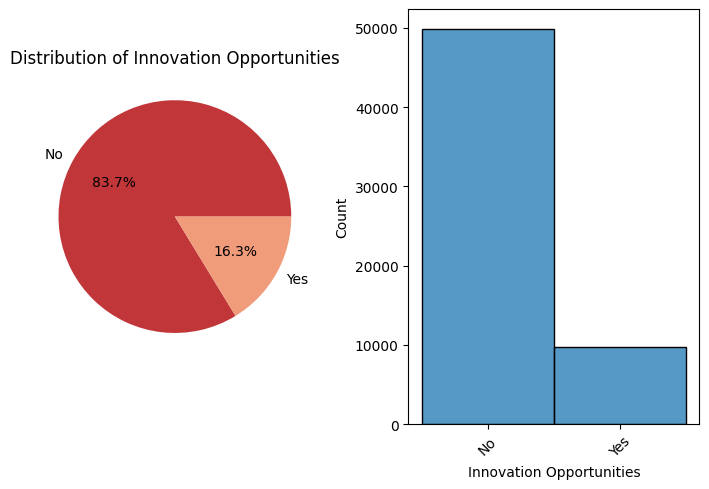

Company Reputation
Good         29766
Poor         12034
Fair         11817
Excellent     5981
Name: count, dtype: int64


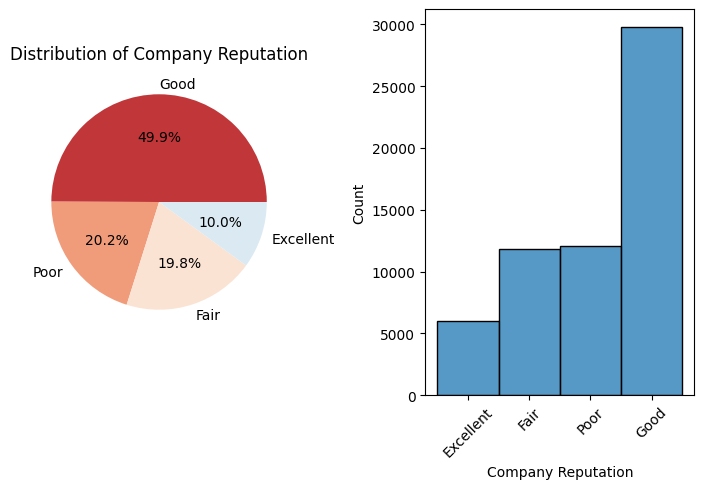

Employee Recognition
Low          23758
Medium       18033
High         14844
Very High     2963
Name: count, dtype: int64


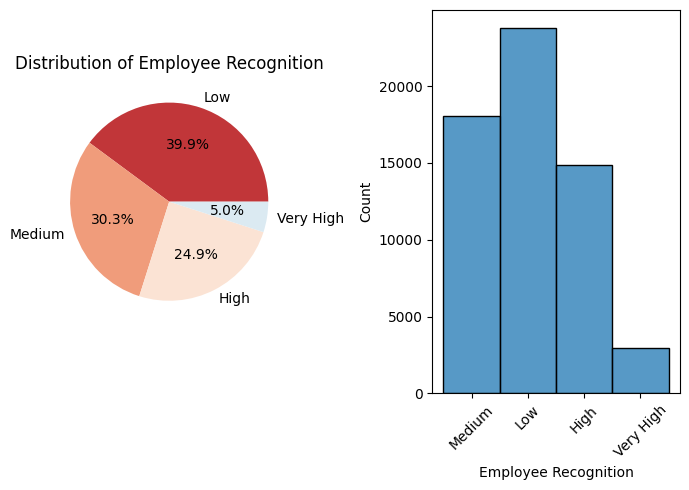

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64


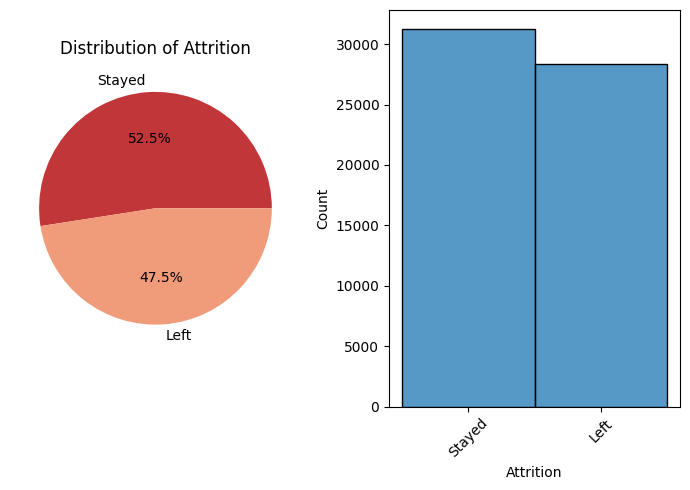

In [16]:
for column in object_data:
    print(data[column].value_counts())
    Vsualize(column,data=data)

In [17]:
 object_data[object_data['Attrition']=='Left']

,Gender,Job Role,Work-Life Balance,Job Satisfaction,Performance Rating,Overtime,Education Level,Marital Status,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
5,Female,Technology,Fair,High,Below Average,No,Bachelor’s Degree,Married,Mid,Medium,No,No,Yes,Fair,High,Left
6,Male,Education,Fair,High,High,Yes,High School,Divorced,Entry,Small,No,No,No,Good,Medium,Left
9,Female,Healthcare,Poor,High,Average,Yes,PhD,Single,Entry,Large,No,No,Yes,Good,Low,Left
10,Female,Education,Good,High,Average,No,High School,Single,Entry,Small,No,No,No,Good,Medium,Left
11,Female,Healthcare,Poor,Medium,Low,No,Master’s Degree,Single,Mid,Medium,No,No,No,Poor,Medium,Left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59590,Male,Healthcare,Fair,High,Average,No,Associate Degree,Married,Mid,Small,No,No,No,Fair,Medium,Left
59591,Male,Technology,Good,High,Average,No,Bachelor’s Degree,Single,Mid,Small,No,No,No,Fair,High,Left
59593,Female,Education,Fair,High,Average,Yes,Bachelor’s Degree,Single,Senior,Small,No,No,Yes,Poor,Very High,Left
59594,Male,Healthcare,Fair,High,High,No,Associate Degree,Single,Senior,Medium,No,No,No,Fair,Medium,Left


In [18]:
left_employe = object_data[object_data['Attrition']=='Left']

In [19]:
left_employe['Attrition'].value_counts()

Attrition
Left    28338
Name: count, dtype: int64

Gender
Female    14279
Male      14059
Name: count, dtype: int64


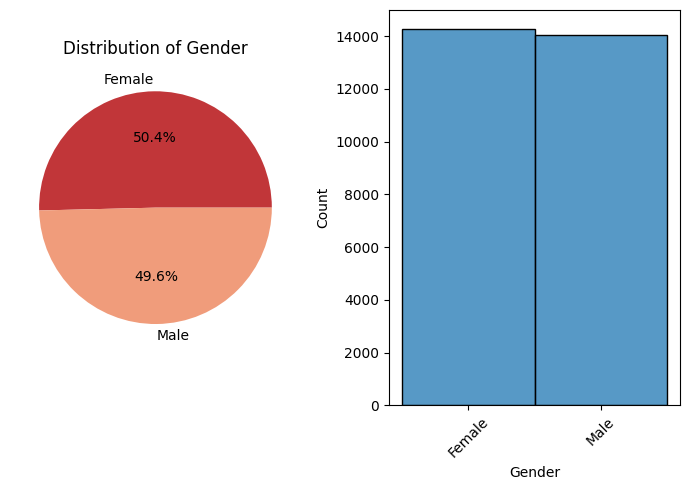

Job Role
Technology    7333
Healthcare    6454
Education     6085
Media         4542
Finance       3924
Name: count, dtype: int64


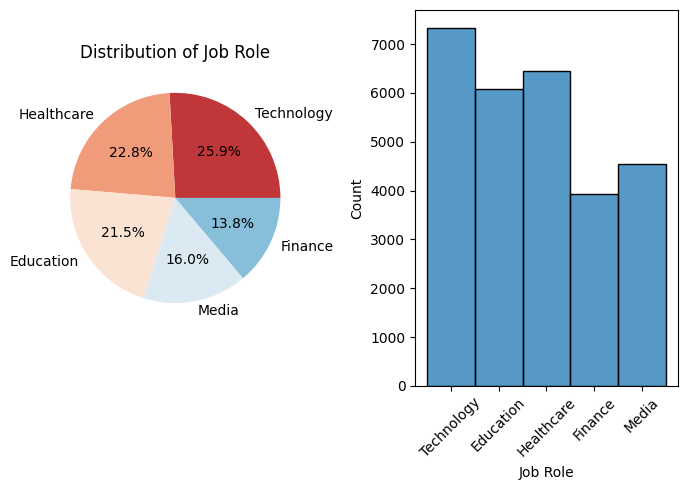

Work-Life Balance
Fair         10370
Good          9137
Poor          4992
Excellent     3839
Name: count, dtype: int64


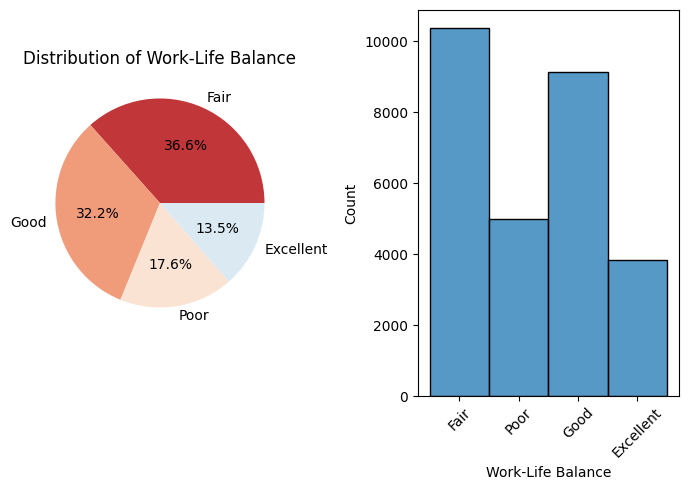

Job Satisfaction
High         13489
Very High     6405
Medium        5356
Low           3088
Name: count, dtype: int64


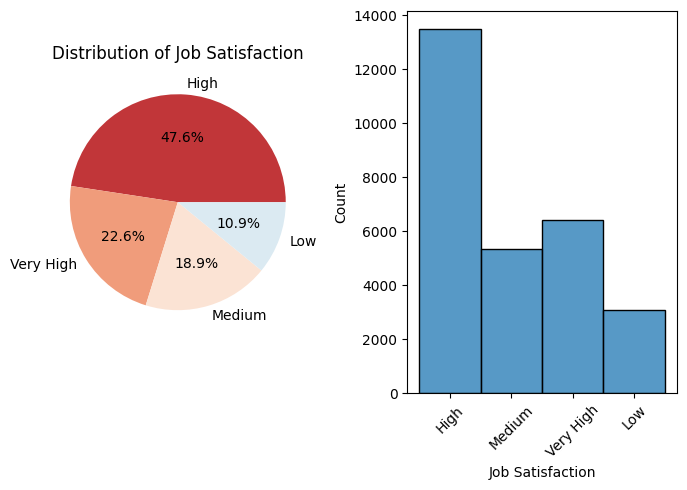

Performance Rating
Average          16527
High              5477
Below Average     4637
Low               1697
Name: count, dtype: int64


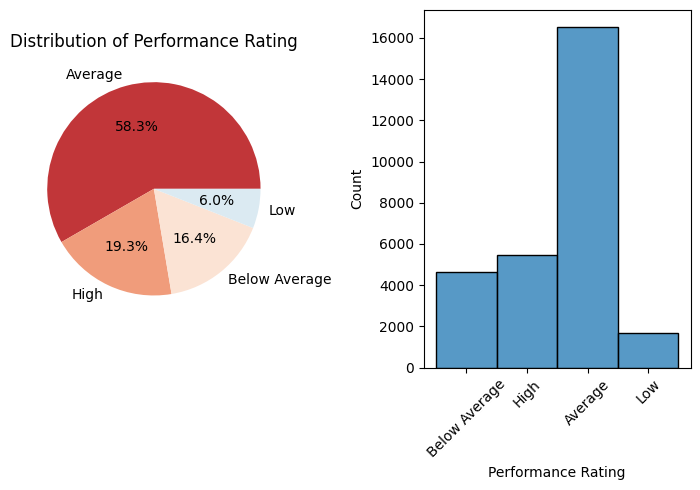

Overtime
No     18313
Yes    10025
Name: count, dtype: int64


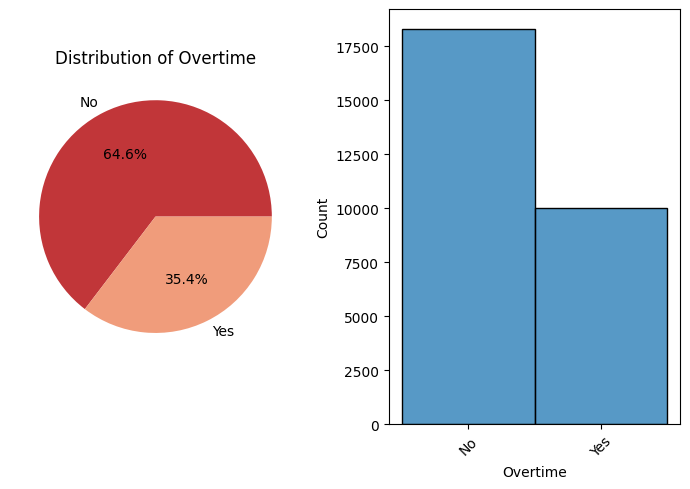

Education Level
Bachelor’s Degree    8791
Associate Degree     7230
Master’s Degree      5881
High School          5668
PhD                   768
Name: count, dtype: int64


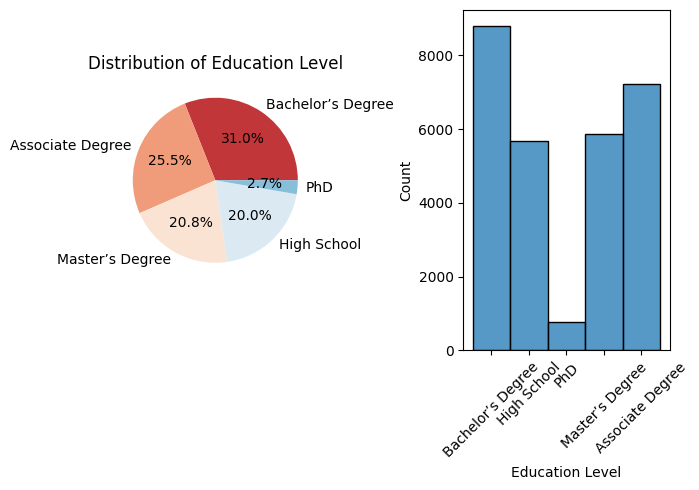

Marital Status
Single      13923
Married     10811
Divorced     3604
Name: count, dtype: int64


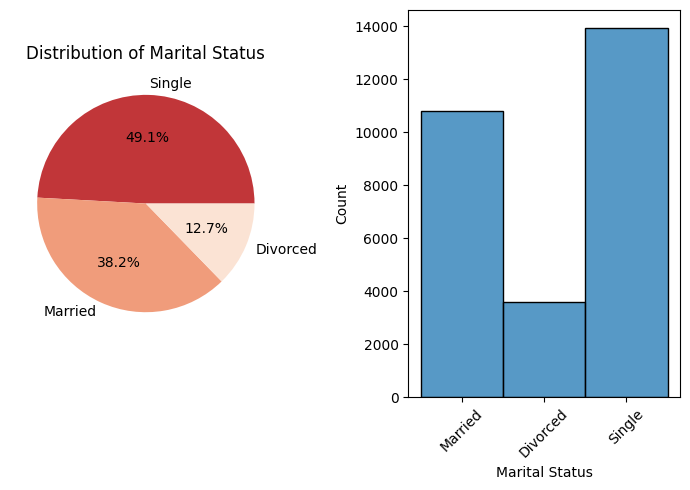

Job Level
Entry     15082
Mid       10823
Senior     2433
Name: count, dtype: int64


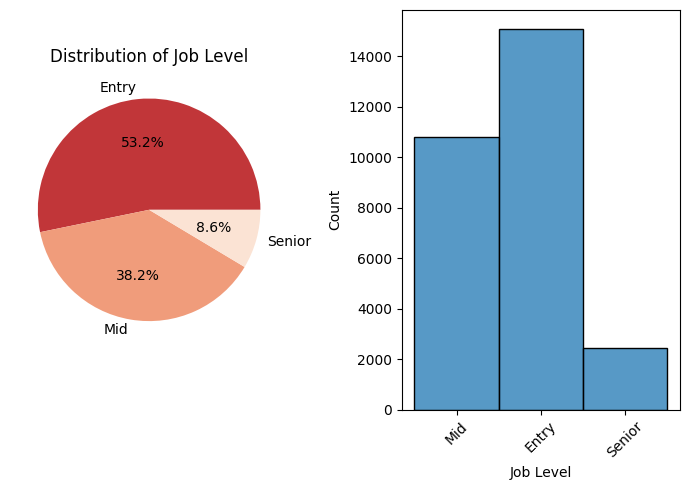

Company Size
Medium    13855
Small      8945
Large      5538
Name: count, dtype: int64


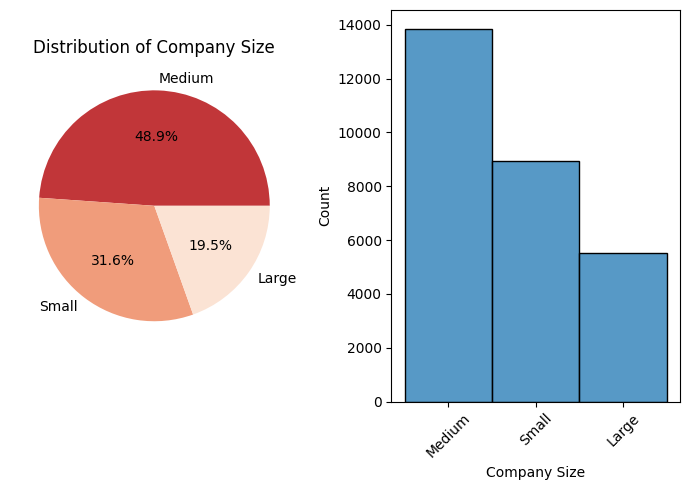

Remote Work
No     25514
Yes     2824
Name: count, dtype: int64


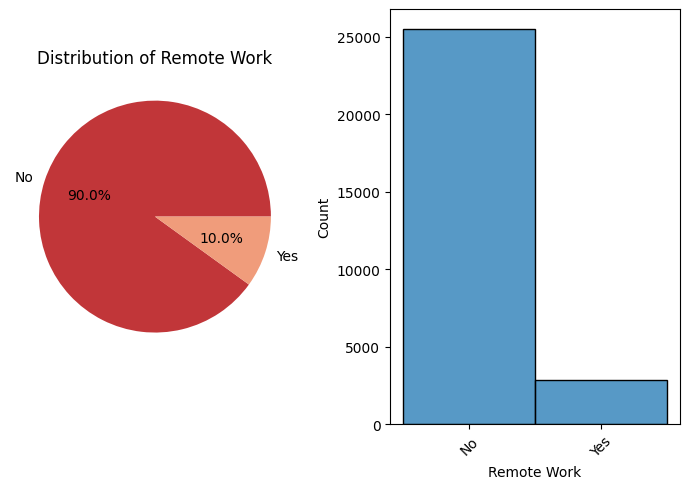

Leadership Opportunities
No     27016
Yes     1322
Name: count, dtype: int64


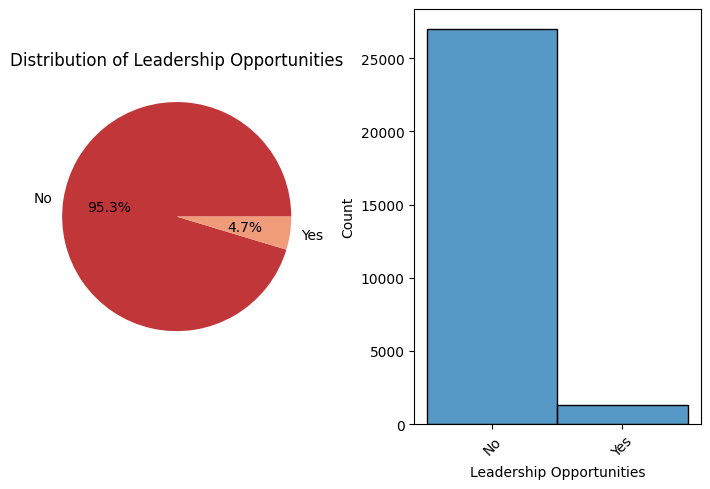

Innovation Opportunities
No     23961
Yes     4377
Name: count, dtype: int64


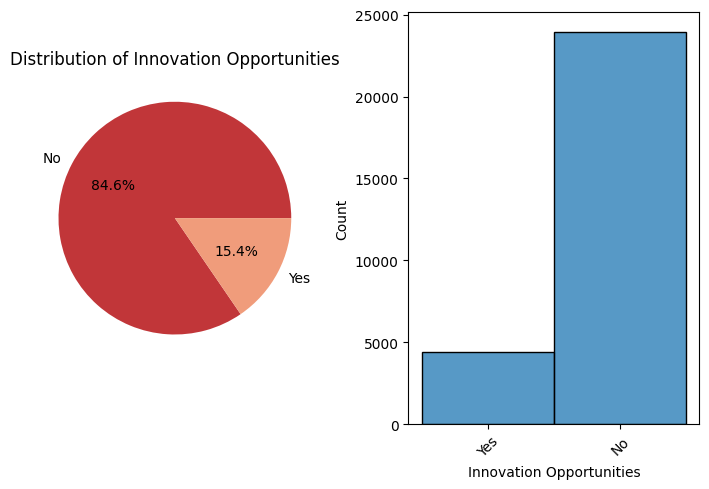

Company Reputation
Good         12774
Poor          6799
Fair          6138
Excellent     2627
Name: count, dtype: int64


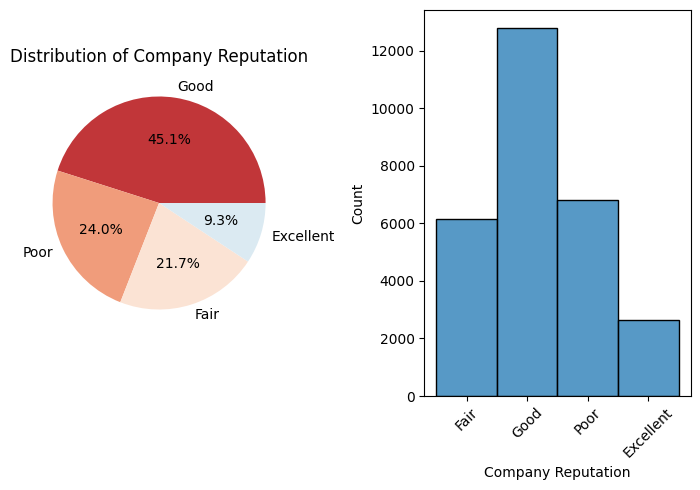

Employee Recognition
Low          11363
Medium        8604
High          7004
Very High     1367
Name: count, dtype: int64


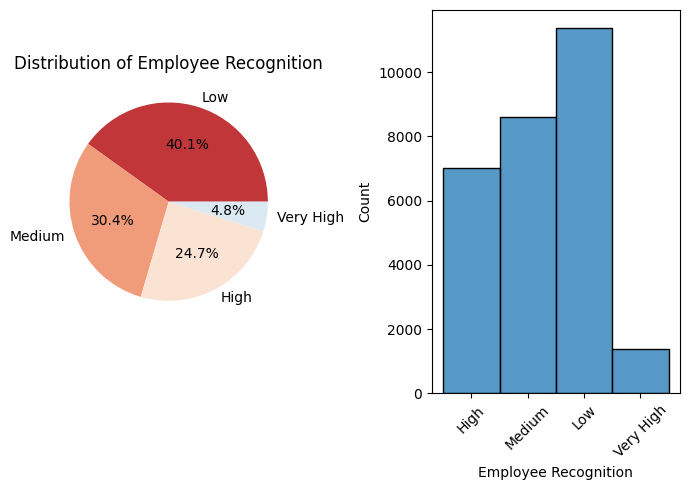

Attrition
Left    28338
Name: count, dtype: int64


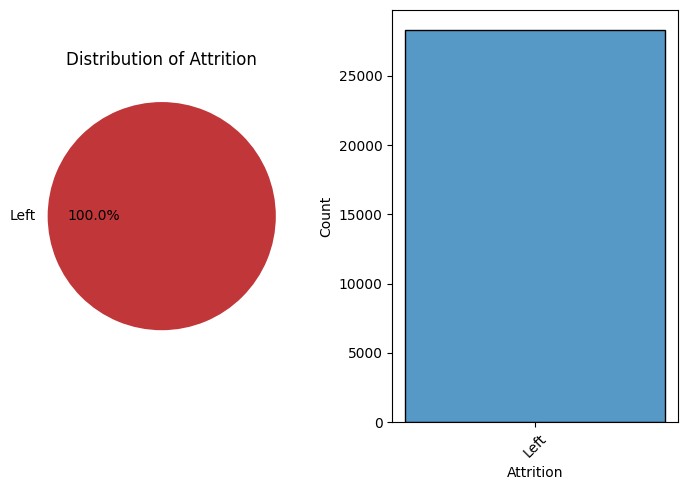

In [20]:
for column in left_employe:
    print(left_employe[column].value_counts())
    Vsualize(column,data=left_employe)

<Axes: xlabel='Gender', ylabel='count'>

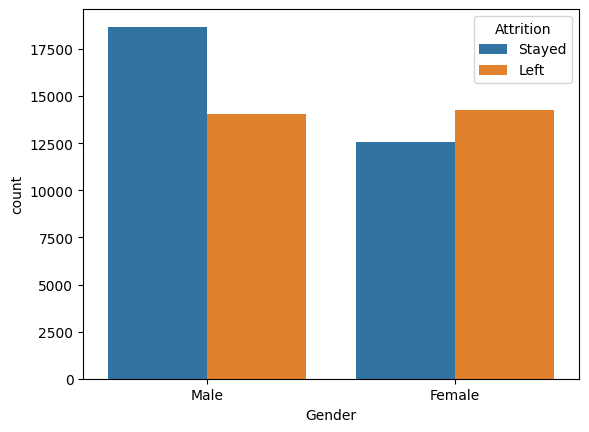

In [21]:
sns.countplot(x=data['Gender'],hue =data['Attrition'] )

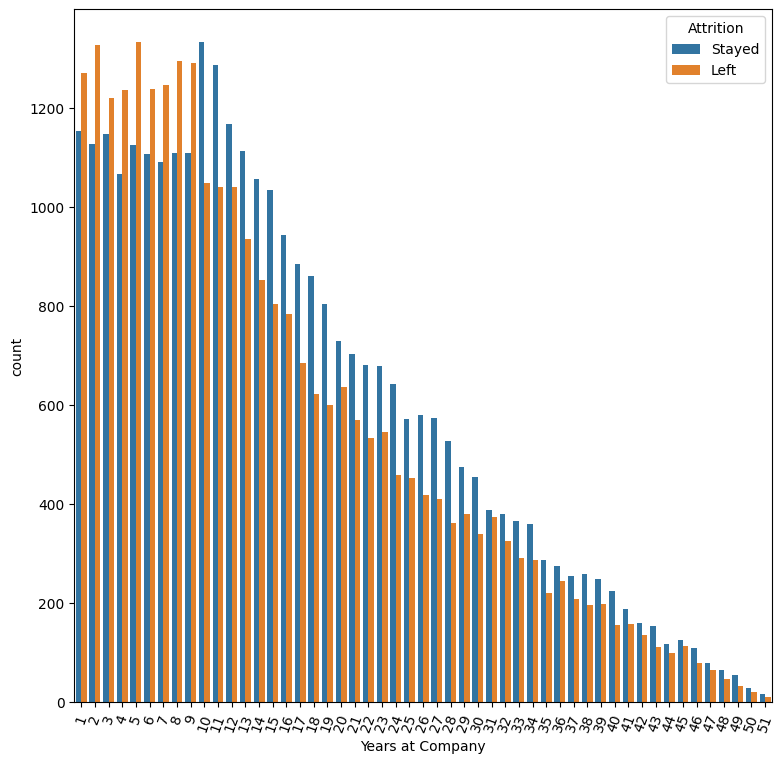

In [22]:
plt.figure(figsize=(9,9))
sns.countplot(x=data['Years at Company'],hue =data['Attrition'] )
plt.xticks(rotation = 70)
plt.show()

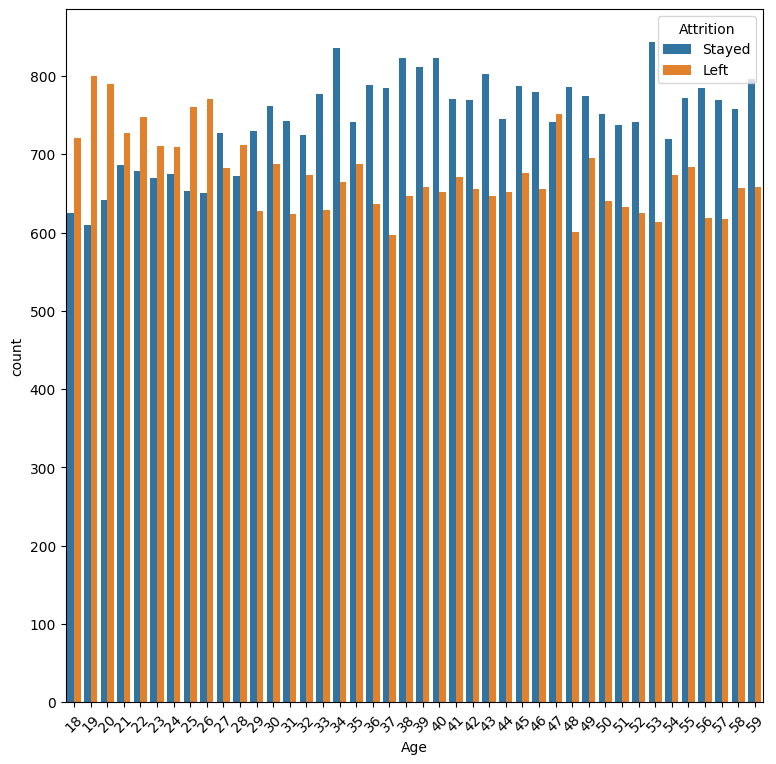

In [23]:
plt.figure(figsize=(9,9))
sns.countplot(x=data['Age'],hue =data['Attrition'] )
plt.xticks(rotation = 45)
plt.show()

## Encoding data

In [24]:
le = LabelEncoder()

In [25]:
# encoding all object features
for column in object_data:
    data[column] = le.fit_transform(data[column])
    print(le.classes_) #to show order of classes

['Female' 'Male']
['Education' 'Finance' 'Healthcare' 'Media' 'Technology']
['Excellent' 'Fair' 'Good' 'Poor']
['High' 'Low' 'Medium' 'Very High']
['Average' 'Below Average' 'High' 'Low']
['No' 'Yes']
['Associate Degree' 'Bachelor’s Degree' 'High School' 'Master’s Degree'
 'PhD']
['Divorced' 'Married' 'Single']
['Entry' 'Mid' 'Senior']
['Large' 'Medium' 'Small']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['Excellent' 'Fair' 'Good' 'Poor']
['High' 'Low' 'Medium' 'Very High']
['Left' 'Stayed']


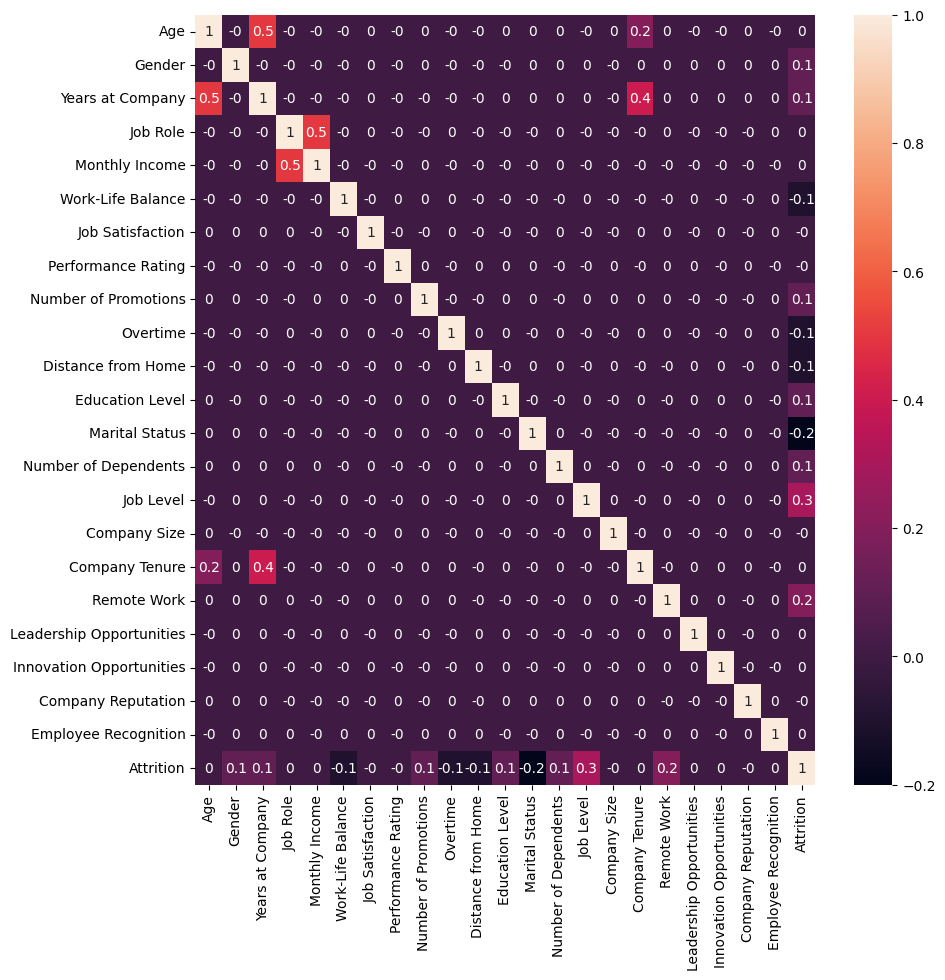

In [26]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr().round(1),annot = True) # round(1) to get one number afer dot
plt.show()

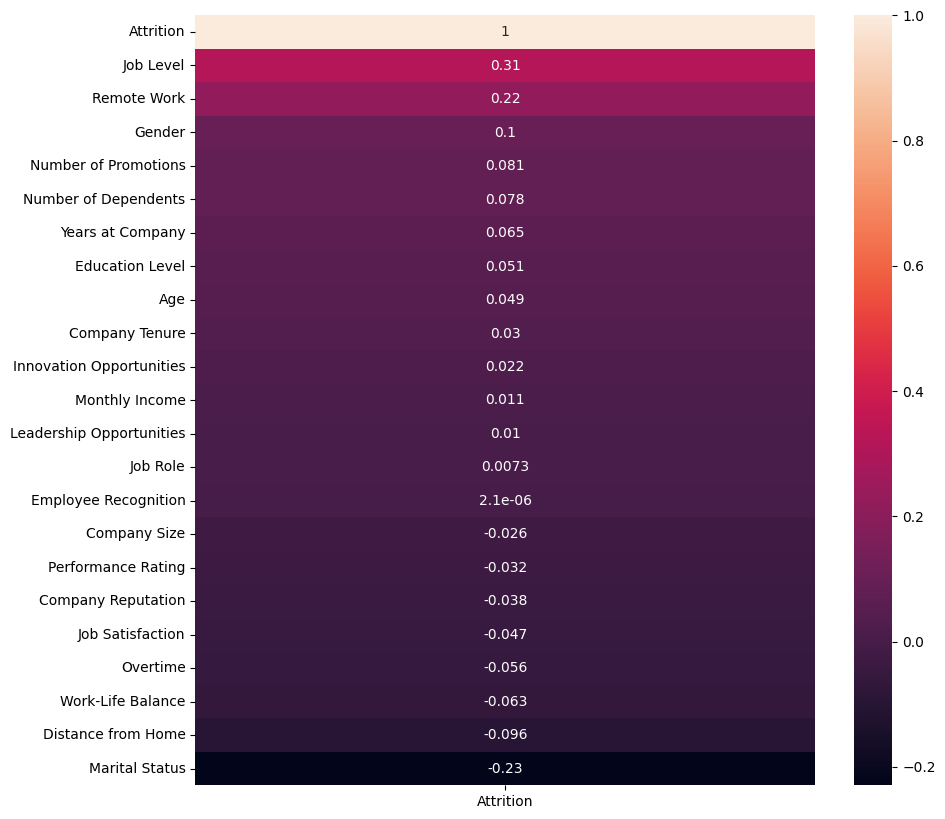

In [27]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr()[['Attrition']].sort_values('Attrition',ascending=False),annot = True)
plt.show()

In [28]:
x_train = data.drop('Attrition',axis = 1)
y_train = data['Attrition']

In [29]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)


## Test Data

In [30]:
test_data = pd.read_csv('/kaggle/input/employee-attrition-dataset/test.csv')


In [31]:
test_data.shape

(14900, 24)

In [32]:
# not important columns
test_data.drop(['Employee ID'],axis = 1,inplace = True)

In [33]:
object_data = test_data.select_dtypes(include='object')
for column in object_data:
  test_data[column] = le.fit_transform(test_data[column])

In [34]:
x_test = test_data.drop(['Attrition'],axis = 1)
y_test = test_data['Attrition']

In [35]:
model = DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state = 45)
train_test_model(model,x_train_scaled,x_test,y_train,y_test)


 Train accuracy_score = 70.41% 


 Test accuracy_score = 64.10% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.70      0.41      0.52      7032
           1       0.62      0.85      0.71      7868

    accuracy                           0.64     14900
   macro avg       0.66      0.63      0.62     14900
weighted avg       0.66      0.64      0.62     14900



In [36]:
model = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state = 45)
train_test_model(model,x_train_scaled,x_test,y_train,y_test)


 Train accuracy_score = 66.00% 


 Test accuracy_score = 62.72% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.65      0.46      0.54      7032
           1       0.62      0.77      0.69      7868

    accuracy                           0.63     14900
   macro avg       0.63      0.62      0.61     14900
weighted avg       0.63      0.63      0.62     14900



In [37]:
model = RandomForestClassifier(n_estimators=7, criterion="entropy", max_depth=5, random_state=45)
train_test_model(model,x_train_scaled,x_test,y_train,y_test)


 Train accuracy_score = 71.57% 


 Test accuracy_score = 60.11% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.59      0.53      0.56      7032
           1       0.61      0.67      0.64      7868

    accuracy                           0.60     14900
   macro avg       0.60      0.60      0.60     14900
weighted avg       0.60      0.60      0.60     14900



In [38]:
model = RandomForestClassifier(n_estimators=10, criterion="gini", max_depth=6, random_state=45)
train_test_model(model,x_train_scaled,x_test,y_train,y_test)


 Train accuracy_score = 73.95% 


 Test accuracy_score = 57.32% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.55      0.52      0.53      7032
           1       0.59      0.62      0.61      7868

    accuracy                           0.57     14900
   macro avg       0.57      0.57      0.57     14900
weighted avg       0.57      0.57      0.57     14900



## Test data with scaling

In [39]:
scaler = StandardScaler()
x_test_scaled = scaler.fit_transform(x_test)

In [40]:
model = DecisionTreeClassifier(criterion='entropy',max_depth=12,random_state = 45)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 77.37% 


 Test accuracy_score = 72.78% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.70      0.73      0.72      7032
           1       0.75      0.72      0.74      7868

    accuracy                           0.73     14900
   macro avg       0.73      0.73      0.73     14900
weighted avg       0.73      0.73      0.73     14900



In [41]:
model = DecisionTreeClassifier(criterion='gini',max_depth=15,random_state = 45)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 84.07% 


 Test accuracy_score = 70.39% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.68      0.71      0.69      7032
           1       0.73      0.70      0.71      7868

    accuracy                           0.70     14900
   macro avg       0.70      0.70      0.70     14900
weighted avg       0.70      0.70      0.70     14900



In [42]:
model = RandomForestClassifier(n_estimators=60, criterion="entropy", max_depth=10, random_state=45)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 76.96% 


 Test accuracy_score = 74.70% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.72      0.75      0.74      7032
           1       0.77      0.75      0.76      7868

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



In [43]:
model = RandomForestClassifier(n_estimators=100, criterion="gini", max_depth=20, random_state=45)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 98.59% 


 Test accuracy_score = 75.00% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.74      0.73      0.73      7032
           1       0.76      0.77      0.76      7868

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



## Another Preprocessing

In [44]:
path = '/kaggle/input/employee-attrition-dataset/train.csv'
df = pd.read_csv(path)

In [45]:
# not important columns
df.drop(['Employee ID'],axis = 1,inplace = True)

In [46]:
object_data = df.select_dtypes(include='object')
for column in object_data:
  df[column] = le.fit_transform(df[column])


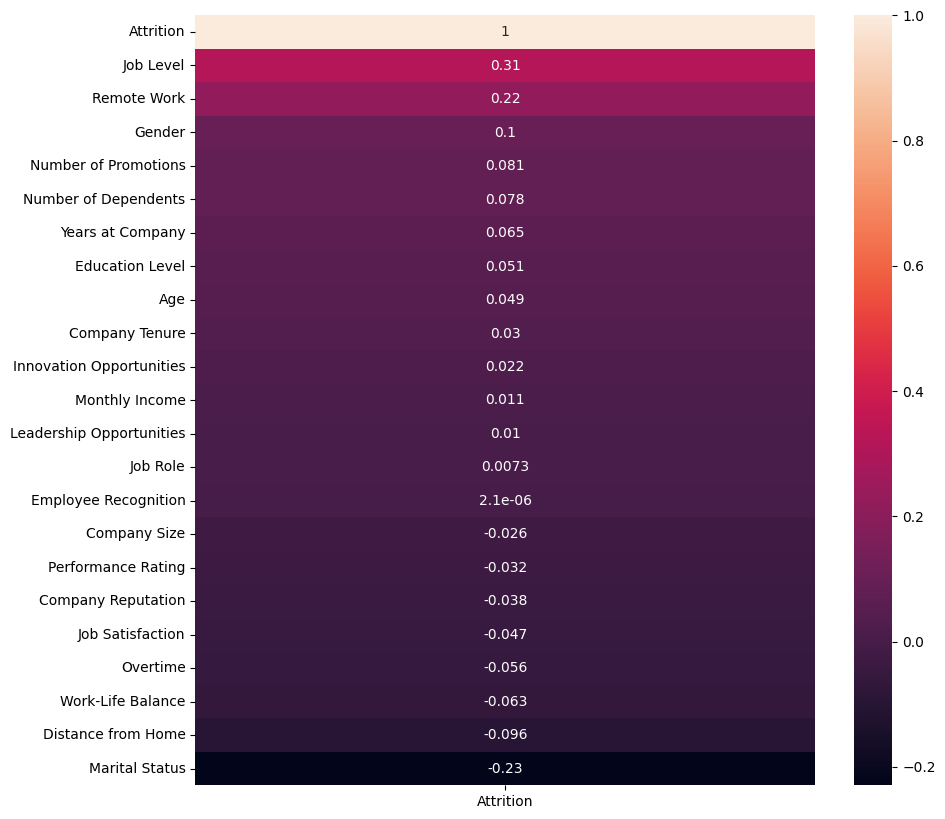

In [47]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr()[['Attrition']].sort_values('Attrition',ascending=False),annot = True)
plt.show()

In [48]:
df.columns

Index(['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Number of Promotions', 'Overtime', 'Distance from Home',
       'Education Level', 'Marital Status', 'Number of Dependents',
       'Job Level', 'Company Size', 'Company Tenure', 'Remote Work',
       'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='object')

In [49]:
# not important columns
df.drop(['Employee Recognition','Company Size','Job Role'],axis = 1,inplace = True)

In [50]:
x_train = df.drop(['Attrition'],axis = 1)
y_train = df['Attrition']

In [51]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)

## Another preprocessing for Test data

In [52]:
x_test = test_data.drop(['Attrition'],axis = 1)
y_test = test_data['Attrition']

In [53]:
# not important columns
x_test.drop(['Employee Recognition','Company Size','Job Role'],axis = 1,inplace = True)

In [54]:
scaler = MinMaxScaler()
x_test_scaled = scaler.fit_transform(x_test)

In [55]:
model = GaussianNB()
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 70.74% 


 Test accuracy_score = 71.35% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.68      0.75      0.71      7032
           1       0.76      0.68      0.71      7868

    accuracy                           0.71     14900
   macro avg       0.72      0.72      0.71     14900
weighted avg       0.72      0.71      0.71     14900



In [56]:
model = LogisticRegression()
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 71.31% 


 Test accuracy_score = 71.76% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.70      0.70      0.70      7032
           1       0.73      0.74      0.73      7868

    accuracy                           0.72     14900
   macro avg       0.72      0.72      0.72     14900
weighted avg       0.72      0.72      0.72     14900



In [57]:
model = SVC(kernel='rbf',C=2,gamma=0.3)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 75.20% 


 Test accuracy_score = 73.66% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.72      0.72      0.72      7032
           1       0.75      0.75      0.75      7868

    accuracy                           0.74     14900
   macro avg       0.74      0.74      0.74     14900
weighted avg       0.74      0.74      0.74     14900



In [58]:
model = RandomForestClassifier(n_estimators=100, criterion="gini", max_depth=20, random_state=45)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 98.35% 


 Test accuracy_score = 74.89% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.74      0.73      0.73      7032
           1       0.76      0.76      0.76      7868

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



In [59]:
model = RandomForestClassifier(n_estimators=50, criterion="entropy", max_depth=9, random_state=45)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 75.95% 


 Test accuracy_score = 74.64% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      7032
           1       0.76      0.76      0.76      7868

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900

